In [1]:
import pandas as pd

In [2]:
memmbers = pd.read_csv("dataset\loyalty_members.csv")
orders = pd.read_csv("dataset\orders.csv")
order_details = pd.read_csv("dataset\order_details.csv")

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
C:\Users\nolan\AppData\Local\Temp\ipykernel_28036\200881336.py:1: SyntaxWarning: invalid escape sequence '\l'
  memmbers = pd.read_csv("dataset\loyalty_members.csv")
C:\Users\nolan\AppData\Local\Temp\ipykernel_28036\200881336.py:2: SyntaxWarning: invalid escape sequence '\o'
  orders = pd.read_csv("dataset\orders.csv")
C:\Users\nolan\AppData\Local\Temp\ipykernel_28036\200881336.py:3: SyntaxWarning: invalid escape sequence '\o'
  order_details = pd.read_csv("dataset\order_details.csv")


In [3]:
memmbers

,loyalty_id,email,tier,points_earned,gender,age,birthday,occupation,name
0,L000002,noah.wilson1@yahoo.com,Frequent,6415,Male,28,1997-03-18,Electrician,Noah Wilson
1,L000005,layla.gonzalez4@icloud.com,Frequent,5245,Female,33,1992-02-18,Software Engineer,Layla Gonzalez
2,L000009,mila.nowak8@yahoo.com,Frequent,7047,Male,25,2000-08-13,Graphic Designer,Mila Nowak
3,L000010,alexander.lau9@hotmail.com,Very Frequent,8769,Male,31,1994-07-16,Project Manager,Alexander Lau
4,L000011,aria.nowak10@icloud.com,Frequent,5417,Female,27,1998-08-26,Barista,Aria Nowak
...,...,...,...,...,...,...,...,...,...
303,L000494,aiden.smith493@outlook.com,Frequent,6683,Male,31,1994-12-02,Student,Aiden Smith
304,L000496,wyatt.su495@icloud.com,Very Frequent,13498,Non-binary,21,2004-04-04,Research Assistant,Wyatt Su
305,L000497,mia.chow496@icloud.com,Very Frequent,14762,Prefer not to say,35,1990-02-06,Accountant,Mia Chow
306,L000499,benjamin.lau498@gmail.com,Very Frequent,11761,Prefer not to say,24,2001-02-03,Research Assistant,Benjamin Lau


In [4]:
orders

,transaction_id,email,transaction_date,time_spent_min,total_bill_amount
0,T000001,mason.chan230@icloud.com,2024-10-28,151,137.94
1,T000002,layla.lam324@icloud.com,2024-10-28,98,71.94
2,T000003,aiden.lam185@hotmail.com,2024-10-28,115,55.45
3,T000004,riley.su43@yahoo.com,2024-10-28,102,147.20
4,T000005,zoey.su268@hotmail.com,2024-10-28,101,160.41
...,...,...,...,...,...
4495,T004496,emma.su325@yahoo.com,2025-10-28,100,34.76
4496,T004497,chloe.wilson133@hotmail.com,2025-10-28,114,56.26
4497,T004498,evelyn.white385@outlook.com,2025-10-28,140,143.70
4498,T004499,oliver.wang362@gmail.com,2025-10-28,80,95.75


In [5]:
fields = [
    "item_type",
    "item_id",
    "item_name",
    "category",
    "unit_price_cad",
    "quantity",
    "line_amount_cad",
]

order_details_subset = order_details[["transaction_id", *fields]].copy()

items_by_txn = (
    order_details_subset
    .groupby("transaction_id", sort=False)[fields]
    .apply(lambda df: df.to_dict(orient="records"))
)

orders = orders.copy()
orders["order_details"] = orders["transaction_id"].map(items_by_txn)

orders.head()

# order_details is a list of dicts, where each dict is an item of the transaction


,transaction_id,email,transaction_date,time_spent_min,total_bill_amount,order_details
0,T000001,mason.chan230@icloud.com,2024-10-28,151,137.94,"[{'item_type': 'food', 'item_id': 'F004', 'ite..."
1,T000002,layla.lam324@icloud.com,2024-10-28,98,71.94,"[{'item_type': 'food', 'item_id': 'F008', 'ite..."
2,T000003,aiden.lam185@hotmail.com,2024-10-28,115,55.45,"[{'item_type': 'food', 'item_id': 'F009', 'ite..."
3,T000004,riley.su43@yahoo.com,2024-10-28,102,147.20,"[{'item_type': 'food', 'item_id': 'F006', 'ite..."
4,T000005,zoey.su268@hotmail.com,2024-10-28,101,160.41,"[{'item_type': 'food', 'item_id': 'F002', 'ite..."


In [6]:
orders["transaction_date"] = pd.to_datetime(orders["transaction_date"])
orders["weekday"] = orders["transaction_date"].dt.day_name()

orders.head()


,transaction_id,email,transaction_date,time_spent_min,total_bill_amount,order_details,weekday
0,T000001,mason.chan230@icloud.com,2024-10-28,151,137.94,"[{'item_type': 'food', 'item_id': 'F004', 'ite...",Monday
1,T000002,layla.lam324@icloud.com,2024-10-28,98,71.94,"[{'item_type': 'food', 'item_id': 'F008', 'ite...",Monday
2,T000003,aiden.lam185@hotmail.com,2024-10-28,115,55.45,"[{'item_type': 'food', 'item_id': 'F009', 'ite...",Monday
3,T000004,riley.su43@yahoo.com,2024-10-28,102,147.20,"[{'item_type': 'food', 'item_id': 'F006', 'ite...",Monday
4,T000005,zoey.su268@hotmail.com,2024-10-28,101,160.41,"[{'item_type': 'food', 'item_id': 'F002', 'ite...",Monday


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

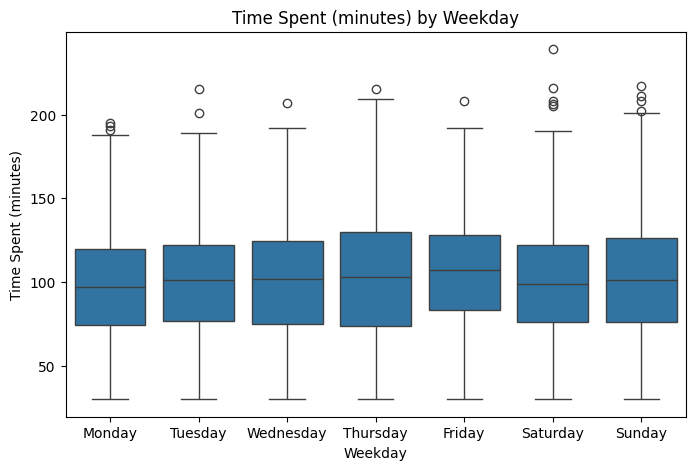

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=orders, x="weekday", y="time_spent_min", order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Time Spent (minutes) by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Time Spent (minutes)")
plt.show()


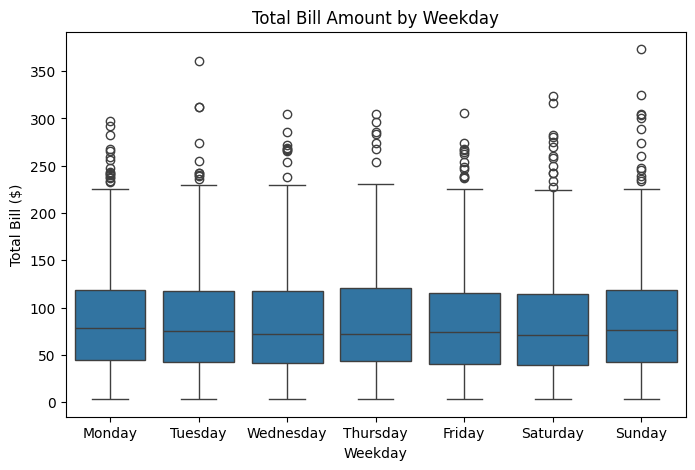

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=orders, x="weekday", y="total_bill_amount", order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Total Bill Amount by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total Bill ($)")
plt.show()


In [10]:
customer = pd.read_csv("dataset\customers.csv")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\nolan\AppData\Local\Temp\ipykernel_28036\466506330.py:1: SyntaxWarning: invalid escape sequence '\c'
  customer = pd.read_csv("dataset\customers.csv")


In [11]:
members = pd.read_csv("dataset\loyalty_members.csv")

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
C:\Users\nolan\AppData\Local\Temp\ipykernel_28036\2272696117.py:1: SyntaxWarning: invalid escape sequence '\l'
  members = pd.read_csv("dataset\loyalty_members.csv")


In [12]:
customers = pd.read_csv("dataset\customers.csv")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\nolan\AppData\Local\Temp\ipykernel_28036\2911203539.py:1: SyntaxWarning: invalid escape sequence '\c'
  customers = pd.read_csv("dataset\customers.csv")


In [13]:
customers['loyalty_enrolled'].value_counts()

loyalty_enrolled
Y    308
N    192
Name: count, dtype: int64

In [14]:
members['tier'].value_counts()

tier
Frequent         179
Very Frequent    126
Casual             3
Name: count, dtype: int64

In [15]:
# Extract email provider (the part between @ and .)
customers["email_provider"] = customers["email"].str.split("@").str[1].str.split(".").str[0]

# Compare loyalty enrollment by email provider
loyalty_by_provider = customers.groupby("email_provider")["loyalty_enrolled"].apply(
    lambda x: pd.Series({
        "total": len(x),
        "enrolled": (x == "Y").sum(),
        "not_enrolled": (x == "N").sum(),
        "enrollment_rate": (x == "Y").mean() * 100
    })
).unstack()

# Sort by enrollment rate
loyalty_by_provider = loyalty_by_provider.sort_values("enrollment_rate", ascending=False)

print("Loyalty Enrollment by Email Provider:")
print(loyalty_by_provider.round(2))


Loyalty Enrollment by Email Provider:
                total  enrolled  not_enrolled  enrollment_rate
email_provider                                                
yahoo           104.0      69.0          35.0            66.35
hotmail         105.0      68.0          37.0            64.76
gmail            85.0      54.0          31.0            63.53
outlook         111.0      64.0          47.0            57.66
icloud           95.0      53.0          42.0            55.79


In [16]:
# Extract email provider (the part between @ and .)
members["email_provider"] = members["email"].str.split("@").str[1].str.split(".").str[0]

# Compare loyalty tier by email provider
tier_by_provider = members.groupby("email_provider")["tier"].apply(
    lambda x: pd.Series({
        "total": len(x),
        "Casual": (x == "Casual").sum(),
        "Frequent": (x == "Frequent").sum(),
        "Very Frequent": (x == "Very Frequent").sum(),
        "casual_rate": (x == "Casual").mean() * 100,
        "frequent_rate": (x == "Frequent").mean() * 100,
        "very_frequent_rate": (x == "Very Frequent").mean() * 100
    })
).unstack()

# Sort by Very Frequent rate (highest tier)
tier_by_provider = tier_by_provider.sort_values("very_frequent_rate", ascending=False)

print("Loyalty Tier Distribution by Email Provider:")
print(tier_by_provider.round(2))


Loyalty Tier Distribution by Email Provider:
                total  Casual  Frequent  Very Frequent  casual_rate  \
email_provider                                                        
icloud           53.0     0.0      27.0           26.0         0.00   
outlook          64.0     0.0      37.0           27.0         0.00   
hotmail          68.0     1.0      39.0           28.0         1.47   
gmail            54.0     0.0      34.0           20.0         0.00   
yahoo            69.0     2.0      42.0           25.0         2.90   

                frequent_rate  very_frequent_rate  
email_provider                                     
icloud                  50.94               49.06  
outlook                 57.81               42.19  
hotmail                 57.35               41.18  
gmail                   62.96               37.04  
yahoo                   60.87               36.23  


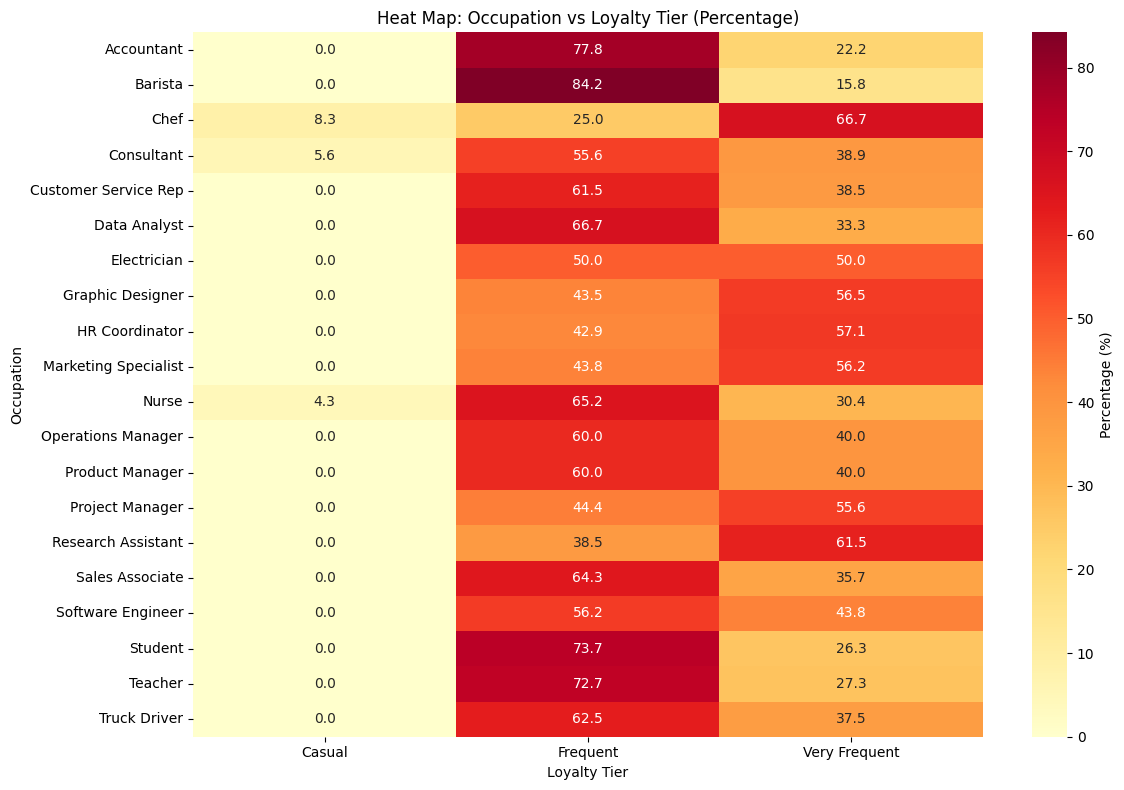

In [17]:
# Create a crosstab of occupation vs tier
occupation_tier_crosstab = pd.crosstab(members["occupation"], members["tier"])

# Normalize by rows (percentage of each occupation in each tier)
occupation_tier_percentage = occupation_tier_crosstab.div(occupation_tier_crosstab.sum(axis=1), axis=0) * 100

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(occupation_tier_percentage, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Heat Map: Occupation vs Loyalty Tier (Percentage)")
plt.xlabel("Loyalty Tier")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()


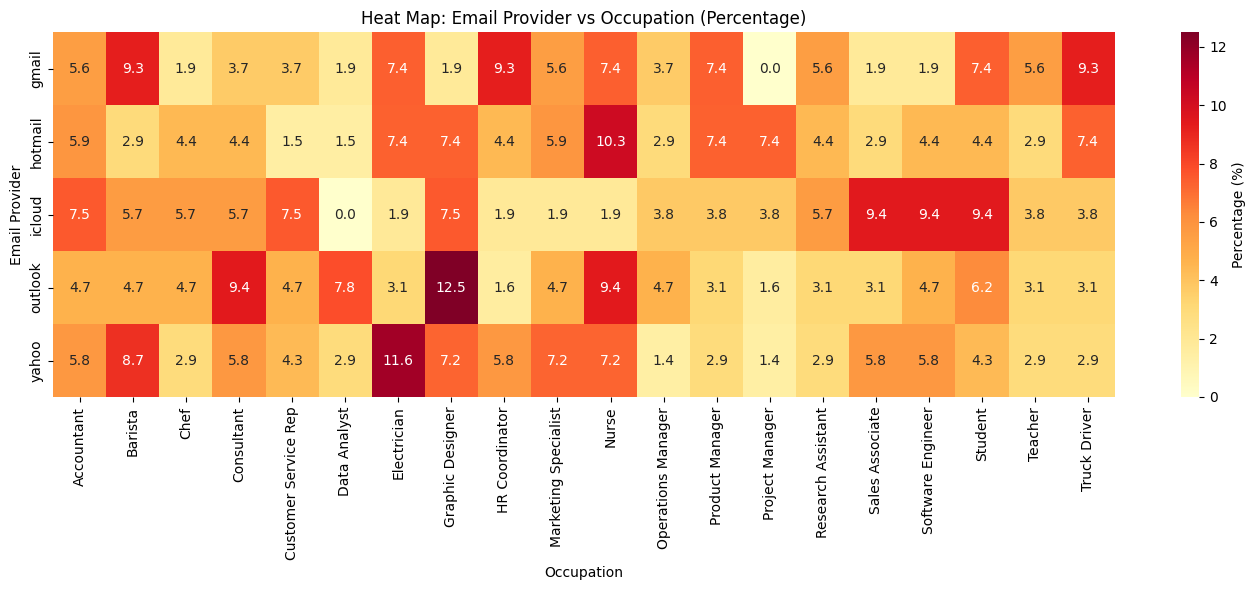

In [18]:
# Create a crosstab of email provider vs occupation
provider_occupation_crosstab = pd.crosstab(members["email_provider"], members["occupation"])

# Normalize by rows (percentage of each email provider in each occupation)
provider_occupation_percentage = provider_occupation_crosstab.div(provider_occupation_crosstab.sum(axis=1), axis=0) * 100

# Create heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(provider_occupation_percentage, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Heat Map: Email Provider vs Occupation (Percentage)")
plt.xlabel("Occupation")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


In [19]:
# Merge orders with members to get tier information
orders_with_tier = orders.merge(members[["email", "tier"]], on="email", how="inner")

print(f"Orders with tier information: {len(orders_with_tier)}")
print(f"Total orders: {len(orders)}")
print(f"\nTier distribution in orders:")
print(orders_with_tier["tier"].value_counts())

orders_with_tier.head()


Orders with tier information: 2791
Total orders: 4500

Tier distribution in orders:
tier
Very Frequent    1428
Frequent         1356
Casual              7
Name: count, dtype: int64


,transaction_id,email,transaction_date,time_spent_min,total_bill_amount,order_details,weekday,tier
0,T000001,mason.chan230@icloud.com,2024-10-28,151,137.94,"[{'item_type': 'food', 'item_id': 'F004', 'ite...",Monday,Frequent
1,T000004,riley.su43@yahoo.com,2024-10-28,102,147.20,"[{'item_type': 'food', 'item_id': 'F006', 'ite...",Monday,Very Frequent
2,T000005,zoey.su268@hotmail.com,2024-10-28,101,160.41,"[{'item_type': 'food', 'item_id': 'F002', 'ite...",Monday,Frequent
3,T000006,oliver.wang362@gmail.com,2024-10-28,67,9.99,"[{'item_type': 'drink', 'item_id': 'D005', 'it...",Monday,Very Frequent
4,T000007,elijah.nowak196@yahoo.com,2024-10-28,110,77.69,"[{'item_type': 'food', 'item_id': 'F011', 'ite...",Monday,Very Frequent


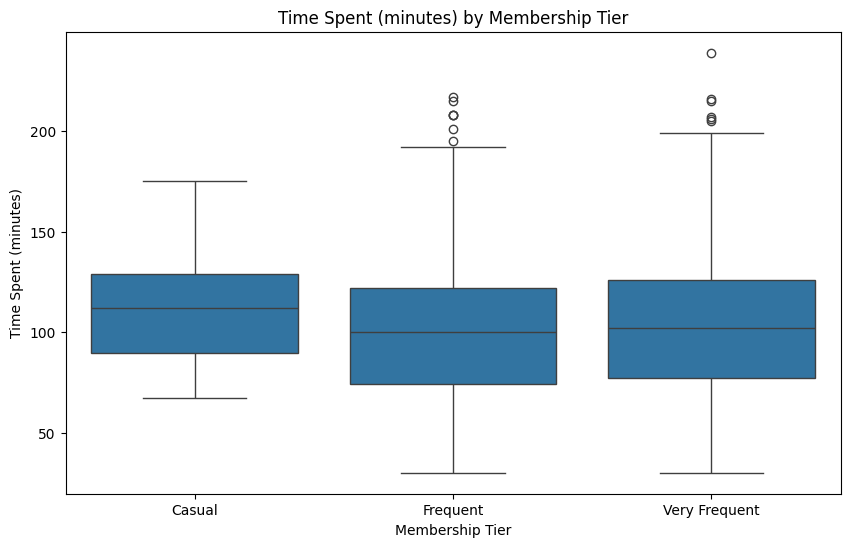

In [20]:
# Boxplot: Time Spent by Membership Tier
plt.figure(figsize=(10, 6))
tier_order = ["Casual", "Frequent", "Very Frequent"]
sns.boxplot(data=orders_with_tier, x="tier", y="time_spent_min", order=tier_order)
plt.title("Time Spent (minutes) by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Time Spent (minutes)")
plt.show()


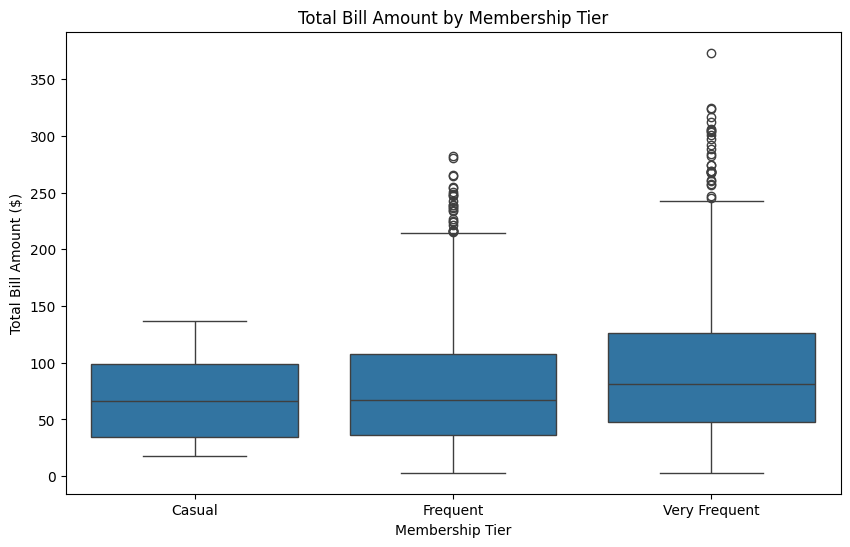

In [21]:
# Boxplot: Total Bill Amount by Membership Tier
plt.figure(figsize=(10, 6))
tier_order = ["Casual", "Frequent", "Very Frequent"]
sns.boxplot(data=orders_with_tier, x="tier", y="total_bill_amount", order=tier_order)
plt.title("Total Bill Amount by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Total Bill Amount ($)")
plt.show()


In [22]:
# Summary statistics by tier
summary_stats = orders_with_tier.groupby("tier")[["time_spent_min", "total_bill_amount"]].agg([
    "mean", "median", "std", "min", "max"
]).round(2)

print("Summary Statistics: Time Spent and Total Bill by Membership Tier")
print(summary_stats)


Summary Statistics: Time Spent and Total Bill by Membership Tier
              time_spent_min                        total_bill_amount         \
                        mean median    std min  max              mean median   
tier                                                                           
Casual                113.00  112.0  37.41  67  175             69.44  66.55   
Frequent               99.73  100.0  35.09  30  217             76.98  67.44   
Very Frequent         101.85  102.0  36.05  30  239             93.12  81.24   

                                     
                 std    min     max  
tier                                 
Casual         43.93  17.48  136.97  
Frequent       51.75   2.99  282.43  
Very Frequent  60.40   2.99  373.24  


In [23]:
# Extract email provider from orders
orders["email_provider"] = orders["email"].str.split("@").str[1].str.split(".").str[0]

# Display provider distribution
print("Email provider distribution in orders:")
print(orders["email_provider"].value_counts())


Email provider distribution in orders:
email_provider
hotmail    970
outlook    964
yahoo      934
icloud     890
gmail      742
Name: count, dtype: int64


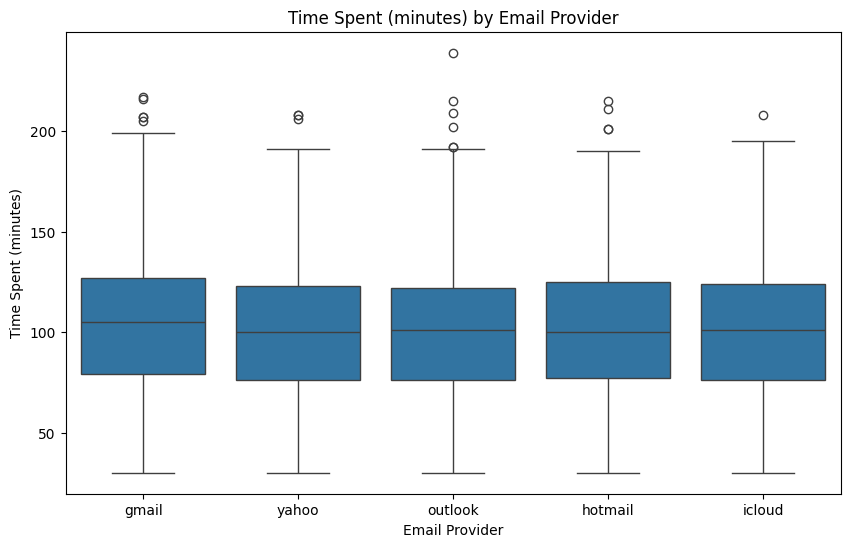

In [24]:
# Boxplot: Time Spent by Email Provider
plt.figure(figsize=(10, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
sns.boxplot(data=orders, x="email_provider", y="time_spent_min", order=provider_order)
plt.title("Time Spent (minutes) by Email Provider")
plt.xlabel("Email Provider")
plt.ylabel("Time Spent (minutes)")
plt.show()


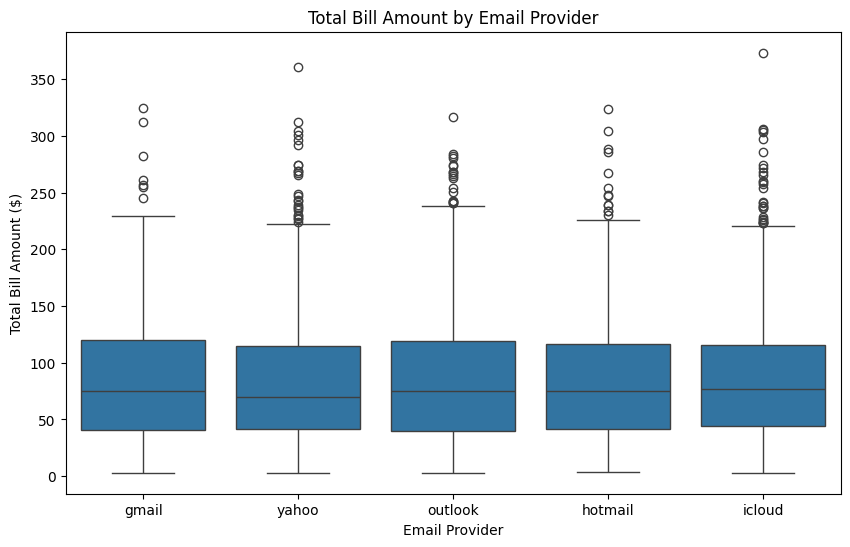

In [25]:
# Boxplot: Total Bill Amount by Email Provider
plt.figure(figsize=(10, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
sns.boxplot(data=orders, x="email_provider", y="total_bill_amount", order=provider_order)
plt.title("Total Bill Amount by Email Provider")
plt.xlabel("Email Provider")
plt.ylabel("Total Bill Amount ($)")
plt.show()


In [26]:
# Summary statistics by email provider
provider_summary = orders.groupby("email_provider")[["time_spent_min", "total_bill_amount"]].agg([
    "mean", "median", "std", "min", "max"
]).round(2)

print("Summary Statistics: Time Spent and Total Bill by Email Provider")
print(provider_summary)


Summary Statistics: Time Spent and Total Bill by Email Provider
               time_spent_min                        total_bill_amount         \
                         mean median    std min  max              mean median   
email_provider                                                                  
gmail                  103.88  105.0  37.04  30  217             85.01  75.44   
hotmail                100.85  100.0  34.18  30  215             85.10  74.69   
icloud                 100.95  101.0  34.94  30  208             85.72  76.62   
outlook                100.45  101.0  35.52  30  239             85.23  74.70   
yahoo                   99.85  100.0  34.33  30  208             83.87  70.12   

                                     
                  std   min     max  
email_provider                       
gmail           55.36  2.99  324.33  
hotmail         55.68  3.29  323.88  
icloud          56.29  2.99  373.24  
outlook         57.40  2.99  316.49  
yahoo           57.35

In [27]:
# Total vs Average vs Median spend by email provider
spend_compare = (
    orders.groupby("email_provider")["total_bill_amount"]
    .agg(total_spend="sum", avg_spend="mean", median_spend="median", order_count="count")
    .round({"total_spend": 2, "avg_spend": 2, "median_spend": 2})
    .sort_values("total_spend", ascending=False)
)

print("Total vs Average vs Median Spend by Email Provider (CAD):")
print(spend_compare)


Total vs Average vs Median Spend by Email Provider (CAD):
                total_spend  avg_spend  median_spend  order_count
email_provider                                                   
hotmail            82542.15      85.10         74.69          970
outlook            82157.29      85.23         74.70          964
yahoo              78332.83      83.87         70.12          934
icloud             76293.63      85.72         76.62          890
gmail              63075.85      85.01         75.44          742


In [28]:
# Derive area_code from customers' phone (e.g., '1-365-227-6804' -> '365')
customers = customers.copy()
customers["area_code"] = customers["phone"].str.split("-").str[1]

# Basic counts of customers by area code
area_code_counts = customers["area_code"].value_counts()
print("Customer counts by area code:")
print(area_code_counts)


Customer counts by area code:
area_code
905    97
365    87
647    84
437    79
289    78
416    75
Name: count, dtype: int64


In [29]:
# Attach area_code to orders and compute spend/time stats
orders_with_area = orders.merge(customers[["email", "area_code"]], on="email", how="left")

area_spend_summary = (
    orders_with_area.groupby("area_code")["total_bill_amount"]
    .agg(total_spend="sum", avg_spend="mean", median_spend="median", order_count="count")
    .round({"total_spend": 2, "avg_spend": 2, "median_spend": 2})
)

area_time_summary = (
    orders_with_area.groupby("area_code")["time_spent_min"]
    .agg(total_time_spent="sum", avg_time="mean", median_time="median")
    .round({"total_time_spent": 0, "avg_time": 2, "median_time": 2})
)

# Merge spend and time summaries
area_order_summary = (
    area_spend_summary.merge(area_time_summary, left_index=True, right_index=True)
    .sort_values("total_spend", ascending=False)
)

print("Orders summary by area code (spend and time):")
print(area_order_summary.head(20))


Orders summary by area code (spend and time):
           total_spend  avg_spend  median_spend  order_count  \
area_code                                                      
905           74514.89      83.82         72.47          889   
365           67032.06      83.79         73.96          800   
437           63127.65      86.71         76.15          728   
647           61318.10      85.76         73.71          715   
289           61060.42      85.88         71.96          711   
416           55348.63      84.24         76.94          657   

           total_time_spent  avg_time  median_time  
area_code                                           
905                   89293    100.44         99.0  
365                   81302    101.63        103.0  
437                   72275     99.28         98.0  
647                   72979    102.07        102.0  
289                   72846    102.46        103.0  
416                   66153    100.69        101.0  


In [30]:
# Membership tier distribution by area code (among members only)
# Attach area_code to members via customers, then compute tier counts and rates
members_with_area = members.merge(customers[["email", "area_code"]], on="email", how="left")

# Counts per tier
tier_counts_by_area = pd.crosstab(members_with_area["area_code"], members_with_area["tier"]).sort_index()

# Row-wise percentages
tier_rates_by_area = tier_counts_by_area.div(tier_counts_by_area.sum(axis=1), axis=0) * 100

tier_counts_and_rates = tier_counts_by_area.join(
    tier_rates_by_area.add_suffix("_rate")
)

print("Membership tier counts and rates by area code (members only):")
print(tier_counts_and_rates.head(20).round(2))


Membership tier counts and rates by area code (members only):
tier       Casual  Frequent  Very Frequent  Casual_rate  Frequent_rate  \
area_code                                                                
289             0        26             25         0.00          50.98   
365             1        31             21         1.89          58.49   
416             0        31             18         0.00          63.27   
437             1        28             18         2.13          59.57   
647             1        31             18         2.00          62.00   
905             0        32             26         0.00          55.17   

tier       Very Frequent_rate  
area_code                      
289                     49.02  
365                     39.62  
416                     36.73  
437                     38.30  
647                     36.00  
905                     44.83  


In [31]:
# Group area codes into two groups and recompute summaries
TORONTO_CORE = {"416", "647", "437"}
OUTER_BELT = {"905", "289", "365"}

# Ensure customers has area_code
if "area_code" not in customers.columns:
    customers = customers.copy()
    customers["area_code"] = customers["phone"].str.split("-").str[1]

# Map to area_group on customers
customers = customers.copy()
customers["area_group"] = customers["area_code"].map(
    lambda ac: "Toronto Core (416/647/437)" if ac in TORONTO_CORE
    else ("Outer Belt (905/289/365)" if ac in OUTER_BELT else "Other")
)

# Counts of customers by group
print("Customer counts by area group:")
print(customers["area_group"].value_counts())

# Attach area_group to orders
orders_with_area_group = orders.merge(customers[["email", "area_group"]], on="email", how="left")

# Spend/time summaries by area_group
group_spend_summary = (
    orders_with_area_group.groupby("area_group")["total_bill_amount"]
    .agg(total_spend="sum", avg_spend="mean", median_spend="median", order_count="count")
    .round({"total_spend": 2, "avg_spend": 2, "median_spend": 2})
)

group_time_summary = (
    orders_with_area_group.groupby("area_group")["time_spent_min"]
    .agg(total_time_spent="sum", avg_time="mean", median_time="median")
    .round({"total_time_spent": 0, "avg_time": 2, "median_time": 2})
)

area_group_order_summary = group_spend_summary.merge(group_time_summary, left_index=True, right_index=True)
print("\nOrders summary by area group:")
print(area_group_order_summary.sort_values("total_spend", ascending=False))

# Tier distribution by area_group among members
members_with_area_group = members.merge(customers[["email", "area_group"]], on="email", how="left")

tier_counts_by_group = pd.crosstab(members_with_area_group["area_group"], members_with_area_group["tier"]).sort_index()
tier_rates_by_group = tier_counts_by_group.div(tier_counts_by_group.sum(axis=1), axis=0) * 100

tier_counts_and_rates_group = tier_counts_by_group.join(tier_rates_by_group.add_suffix("_rate"))
print("\nMembership tier counts and rates by area group:")
print(tier_counts_and_rates_group.round(2))

Customer counts by area group:
area_group
Outer Belt (905/289/365)      262
Toronto Core (416/647/437)    238
Name: count, dtype: int64

Orders summary by area group:
                            total_spend  avg_spend  median_spend  order_count  \
area_group                                                                      
Outer Belt (905/289/365)      202607.37      84.42         72.90         2400   
Toronto Core (416/647/437)    179794.38      85.62         75.43         2100   

                            total_time_spent  avg_time  median_time  
area_group                                                           
Outer Belt (905/289/365)              243441    101.43        102.0  
Toronto Core (416/647/437)            211407    100.67        100.0  

Membership tier counts and rates by area group:
tier                        Casual  Frequent  Very Frequent  Casual_rate  \
area_group                                                                 
Outer Belt (905/289/365)   

In [32]:
# Weekday distribution by Email Provider
weekday_provider_crosstab = pd.crosstab(orders["email_provider"], orders["weekday"])
weekday_provider_percentage = weekday_provider_crosstab.div(weekday_provider_crosstab.sum(axis=1), axis=0) * 100

print("Weekday distribution by Email Provider (Row Percentages):")
print(weekday_provider_percentage.round(2))


Weekday distribution by Email Provider (Row Percentages):
weekday         Friday  Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
email_provider                                                                
gmail            11.99   12.80     16.98   21.43     11.19    13.34      12.26
hotmail          13.20   12.16     19.18   20.52     10.72    12.37      11.86
icloud           12.36   13.26     18.31   17.87     13.03    12.47      12.70
outlook          11.83   13.38     18.57   19.29     11.00    13.28      12.66
yahoo            12.85   13.92     19.70   18.84     11.13    12.96      10.60


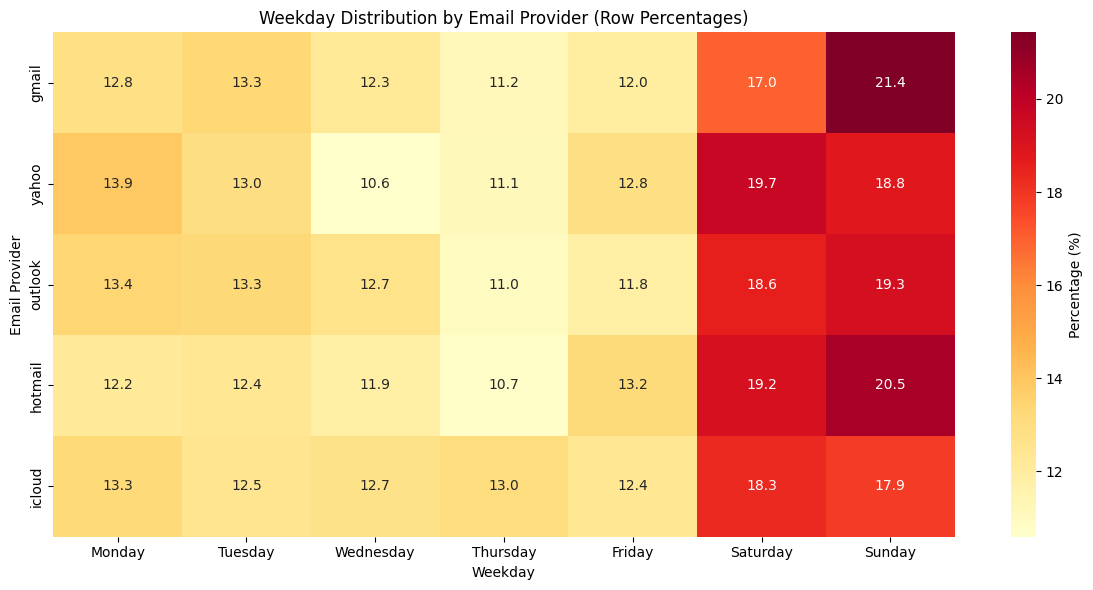

In [33]:
# Weekday distribution by Email Provider - Heatmap
plt.figure(figsize=(12, 6))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
sns.heatmap(weekday_provider_percentage.loc[provider_order, weekday_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Weekday Distribution by Email Provider (Row Percentages)")
plt.xlabel("Weekday")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


In [34]:
# Weekday distribution by Area Code
weekday_area_crosstab = pd.crosstab(orders_with_area["area_code"], orders_with_area["weekday"])
weekday_area_percentage = weekday_area_crosstab.div(weekday_area_crosstab.sum(axis=1), axis=0) * 100

print("Weekday distribution by Area Code (Row Percentages):")
print(weekday_area_percentage.round(2))


Weekday distribution by Area Code (Row Percentages):
weekday    Friday  Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
area_code                                                                
289         13.92   12.94     18.42   17.02     11.53    13.50      12.66
365         12.62   14.00     17.38   20.38     11.75    12.38      11.50
416         10.96   14.46     17.66   20.24     13.55    12.79      10.35
437         13.32   12.09     18.27   18.82     10.30    14.70      12.50
647         11.89   12.03     18.32   20.84     11.47    12.31      13.15
905         12.04   13.16     21.15   19.80     10.24    11.81      11.81


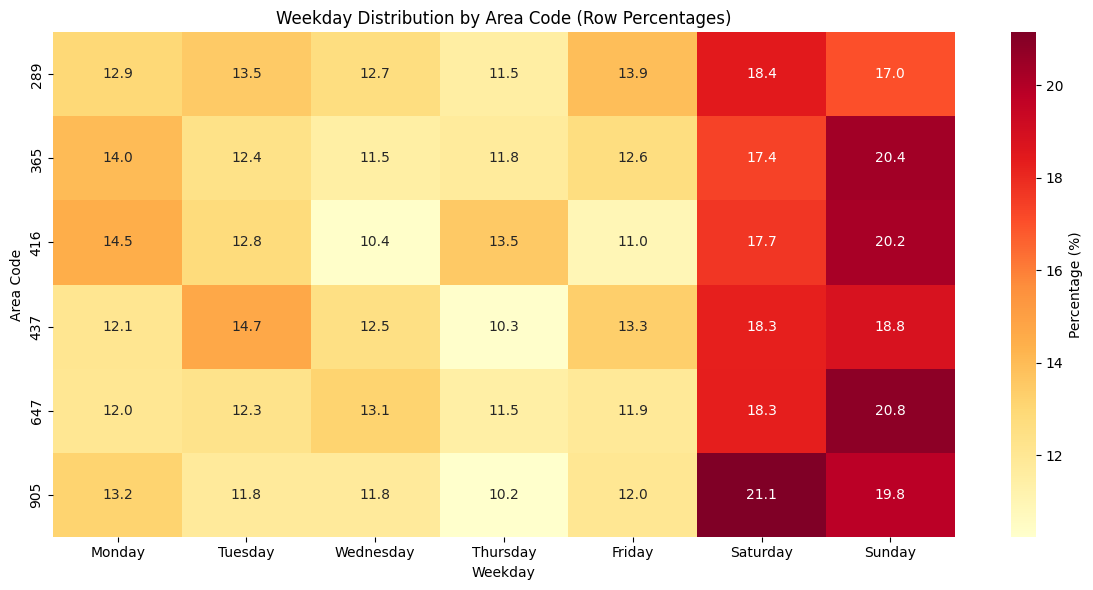

In [35]:
# Weekday distribution by Area Code - Heatmap
plt.figure(figsize=(12, 6))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
area_order = sorted(weekday_area_percentage.index)  # Sort by area code
sns.heatmap(weekday_area_percentage.loc[area_order, weekday_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Weekday Distribution by Area Code (Row Percentages)")
plt.xlabel("Weekday")
plt.ylabel("Area Code")
plt.tight_layout()
plt.show()


In [36]:
# Weekday distribution by Area Group (Toronto Core vs Outer Belt)
weekday_area_group_crosstab = pd.crosstab(orders_with_area_group["area_group"], orders_with_area_group["weekday"])
weekday_area_group_percentage = weekday_area_group_crosstab.div(weekday_area_group_crosstab.sum(axis=1), axis=0) * 100

print("Weekday distribution by Area Group (Row Percentages):")
print(weekday_area_group_percentage.round(2))


Weekday distribution by Area Group (Row Percentages):
weekday                     Friday  Monday  Saturday  Sunday  Thursday  \
area_group                                                               
Outer Belt (905/289/365)     12.79   13.38     19.08   19.17     11.12   
Toronto Core (416/647/437)   12.10   12.81     18.10   19.95     11.71   

weekday                     Tuesday  Wednesday  
area_group                                      
Outer Belt (905/289/365)      12.50      11.96  
Toronto Core (416/647/437)    13.29      12.05  


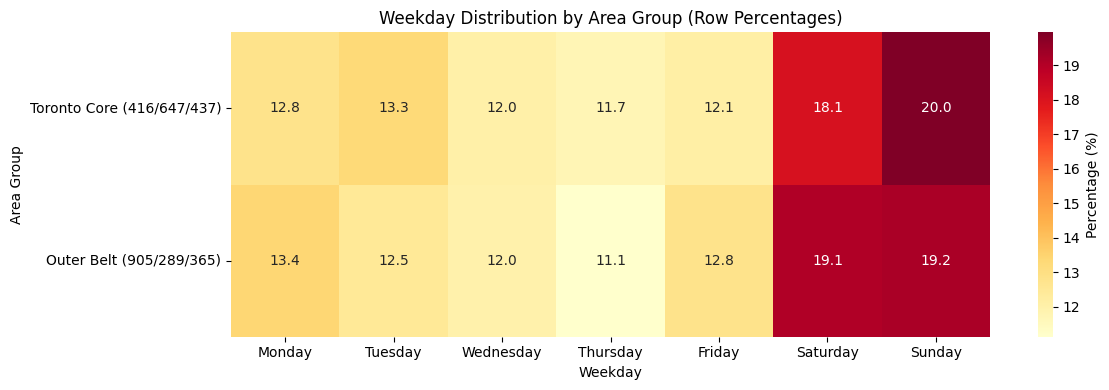

In [37]:
# Weekday distribution by Area Group - Heatmap
plt.figure(figsize=(12, 4))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
group_order = ["Toronto Core (416/647/437)", "Outer Belt (905/289/365)"]
sns.heatmap(weekday_area_group_percentage.loc[group_order, weekday_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Weekday Distribution by Area Group (Row Percentages)")
plt.xlabel("Weekday")
plt.ylabel("Area Group")
plt.tight_layout()
plt.show()


In [38]:
# Weekday distribution by Membership Tier
weekday_tier_crosstab = pd.crosstab(orders_with_tier["tier"], orders_with_tier["weekday"])
weekday_tier_percentage = weekday_tier_crosstab.div(weekday_tier_crosstab.sum(axis=1), axis=0) * 100

print("Weekday distribution by Membership Tier (Row Percentages):")
print(weekday_tier_percentage.round(2))


Weekday distribution by Membership Tier (Row Percentages):
weekday        Friday  Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
tier                                                                         
Casual           0.00    0.00     14.29   14.29     28.57    14.29      28.57
Frequent        13.13   13.86     18.58   19.54     11.65    12.17      11.06
Very Frequent   11.90   13.73     18.84   19.26     11.34    13.17      11.76


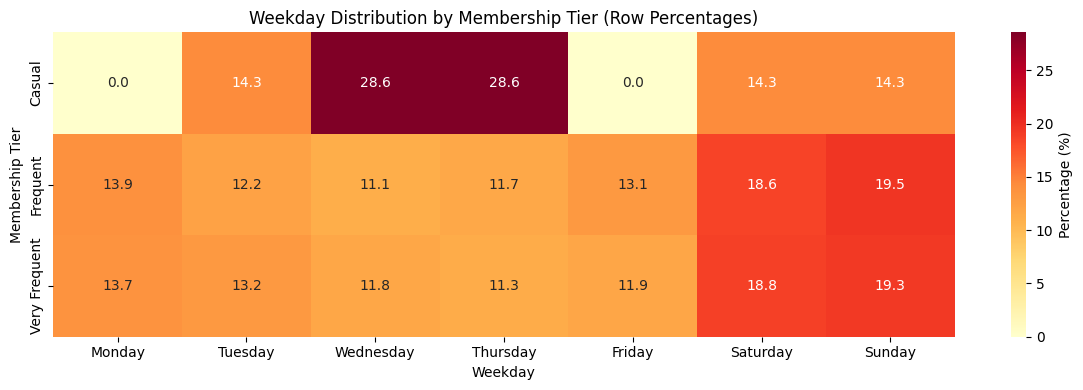

In [ ]:
# Weekday distribution by Membership Tier - Heatmap
plt.figure(figsize=(12, 4))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
tier_order = ["Casual", "Frequent", "Very Frequent"]
sns.heatmap(weekday_tier_percentage.loc[tier_order, weekday_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Weekday Distribution by Membership Tier (Row Percentages)")
plt.xlabel("Weekday")
plt.ylabel("Membership Tier")
plt.tight_layout()
plt.show()

# this might be bad as there are only 7 casual members

In [40]:
# Extract email provider from order_details
order_details["email_provider"] = order_details["email"].str.split("@").str[1].str.split(".").str[0]

# Category distribution by Email Provider (counts and percentages)
category_provider_crosstab = pd.crosstab(order_details["email_provider"], order_details["category"])
category_provider_percentage = category_provider_crosstab.div(category_provider_crosstab.sum(axis=1), axis=0) * 100

print("Category distribution by Email Provider (Row Percentages):")
print(category_provider_percentage.round(2))


Category distribution by Email Provider (Row Percentages):
category        Air Hockey  Alcoholic  Appetizers  Arcade  Billiards  Bowling  \
email_provider                                                                  
gmail                 4.07       9.83        7.35   10.38       3.44     3.38   
hotmail               3.66      10.39        7.54   10.96       3.40     3.61   
icloud                4.07      10.56        7.00   11.04       3.46     3.69   
outlook               3.61      10.42        7.32   10.82       3.65     3.52   
yahoo                 3.61      10.29        7.01   11.55       3.95     3.83   

category        Cocktail  Desserts  Mains  Non-alcoholic  Salads    VR  
email_provider                                                          
gmail              10.50      4.49  14.53          26.33    2.23  3.47  
hotmail            10.59      4.75  14.18          24.89    2.08  3.95  
icloud             10.08      4.94  13.56          25.34    2.38  3.88  
outlook 

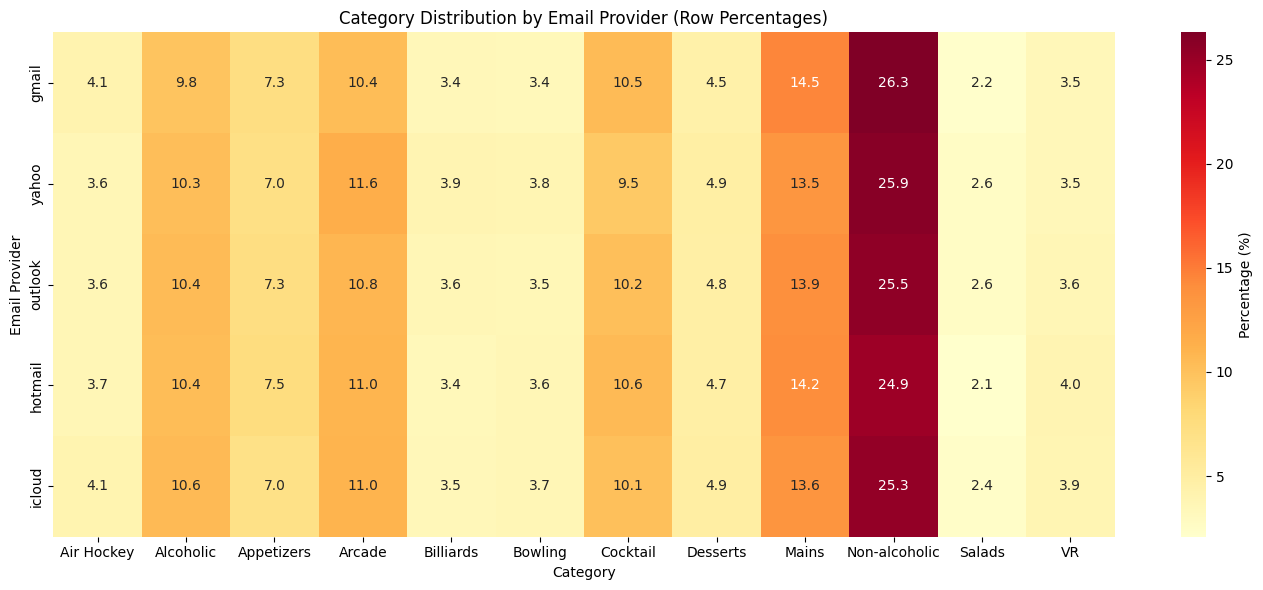

In [41]:
# Category distribution by Email Provider - Heatmap
plt.figure(figsize=(14, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
category_order = sorted(category_provider_percentage.columns)
sns.heatmap(category_provider_percentage.loc[provider_order, category_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Category Distribution by Email Provider (Row Percentages)")
plt.xlabel("Category")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


In [42]:
# Total spending by category for each email provider
category_spend_by_provider = (
    order_details.groupby(["email_provider", "category"])["line_amount_cad"]
    .sum()
    .unstack(fill_value=0)
)

print("Total Spending by Category by Email Provider (CAD):")
print(category_spend_by_provider.round(2))


Total Spending by Category by Email Provider (CAD):
category        Air Hockey  Alcoholic  Appetizers   Arcade  Billiards  \
email_provider                                                          
gmail               1818.0    5543.49     5374.19  12150.0     3078.0   
hotmail             2106.0    7332.06     7239.25  16370.0     3924.0   
icloud              2232.0    7214.16     6083.65  14710.0     3888.0   
outlook             2070.0    7360.08     7089.54  15920.0     4230.0   
yahoo               2016.0    6967.98     6363.01  15940.0     4302.0   

category        Bowling  Cocktail  Desserts     Mains  Non-alcoholic   Salads  \
email_provider                                                                  
gmail            1344.0   7948.86   1997.21  14172.44        5612.55  1473.82   
hotmail          1856.0  10377.49   2753.85  18014.05        7053.36  1723.62   
icloud           1784.0   9497.70   2764.83  15970.99        6729.67  1910.97   
outlook          1800.0  10316.

Percentage of Total Spending by Category by Email Provider:
category        Air Hockey  Alcoholic  Appetizers  Arcade  Billiards  Bowling  \
email_provider                                                                  
gmail                 2.88       8.79        8.52   19.26       4.88     2.13   
hotmail               2.55       8.88        8.77   19.83       4.75     2.25   
icloud                2.93       9.46        7.97   19.28       5.10     2.34   
outlook               2.52       8.96        8.63   19.38       5.15     2.19   
yahoo                 2.57       8.90        8.12   20.35       5.49     2.41   

category        Cocktail  Desserts  Mains  Non-alcoholic  Salads    VR  
email_provider                                                          
gmail              12.60      3.17  22.47           8.90    2.34  4.06  
hotmail            12.57      3.34  21.82           8.55    2.09  4.59  
icloud             12.45      3.62  20.93           8.82    2.50  4.60  
outlook

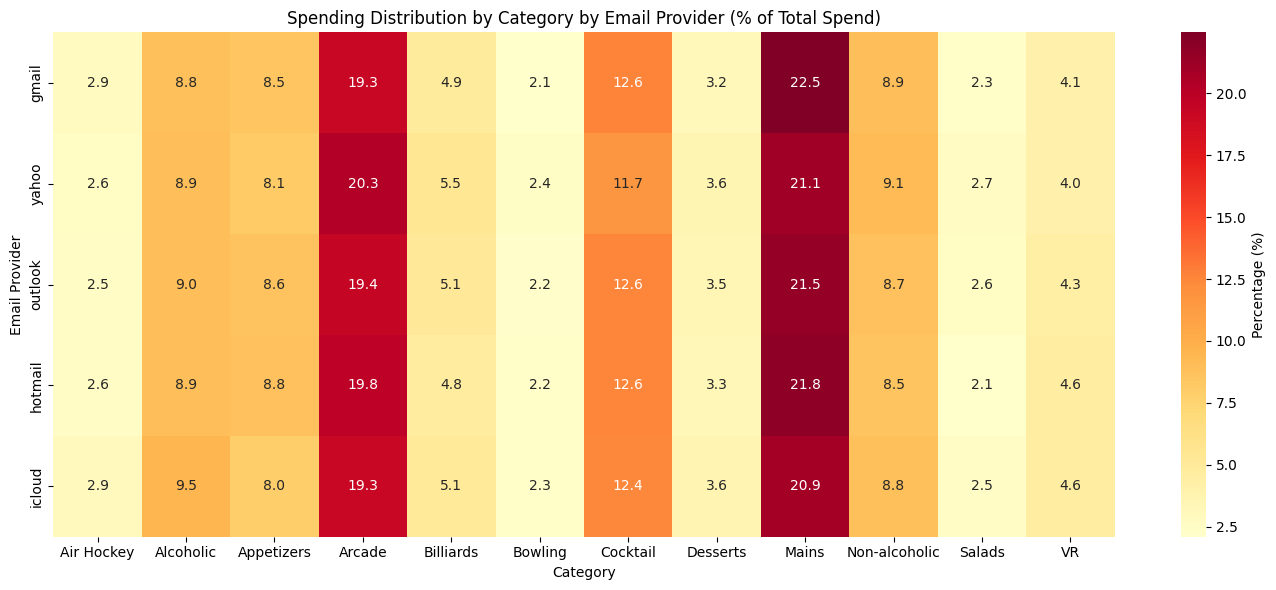

In [ ]:
# Percentage of total spending by category for each email provider
category_spend_percent_by_provider = category_spend_by_provider.div(category_spend_by_provider.sum(axis=1), axis=0) * 100

print("Percentage of Total Spending by Category by Email Provider:")
print(category_spend_percent_by_provider.round(2))

# Heatmap
plt.figure(figsize=(14, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
category_order = sorted(category_spend_percent_by_provider.columns)
sns.heatmap(category_spend_percent_by_provider.loc[provider_order, category_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Spending Distribution by Category by Email Provider (% of Total Spend)")
plt.xlabel("Category")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


In [44]:
# Age statistics by Email Provider (using members data)
# Extract email provider from members if not already present
if "email_provider" not in members.columns:
    members["email_provider"] = members["email"].str.split("@").str[1].str.split(".").str[0]

age_by_provider = members.groupby("email_provider")["age"].agg([
    "count", "mean", "median", "std", "min", "max"
]).round(2)

print("Age Statistics by Email Provider (from Members):")
print(age_by_provider)


Age Statistics by Email Provider (from Members):
                count   mean  median    std  min  max
email_provider                                       
gmail              54  29.48    27.5   8.58   18   50
hotmail            68  31.99    31.0   8.68   18   56
icloud             53  33.21    33.0  10.16   18   58
outlook            64  32.19    31.5   8.74   18   54
yahoo              69  31.32    31.0   8.83   18   58


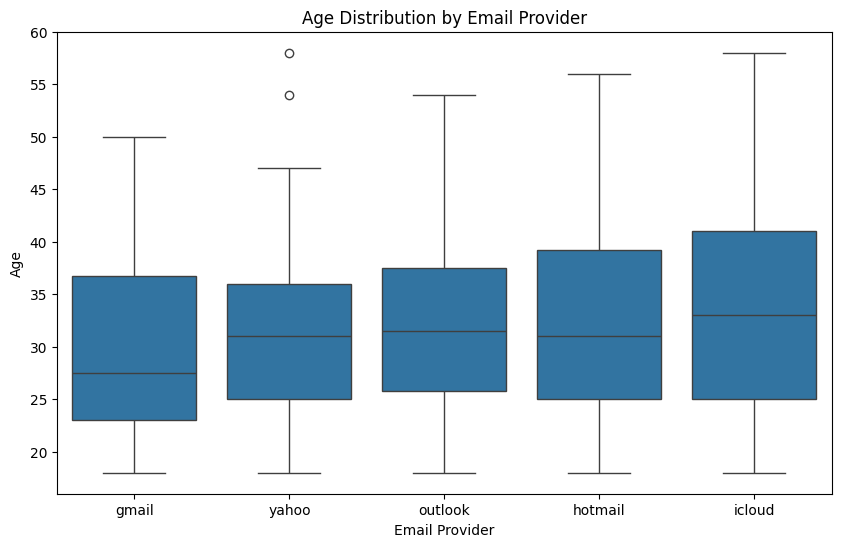

In [45]:
# Boxplot: Age distribution by Email Provider
plt.figure(figsize=(10, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
sns.boxplot(data=members, x="email_provider", y="age", order=provider_order)
plt.title("Age Distribution by Email Provider")
plt.xlabel("Email Provider")
plt.ylabel("Age")
plt.show()


Age Group distribution by Email Provider (Row Percentages):
age_group       18-25  26-30  31-35  36-40    41+
email_provider                                   
gmail           42.59  18.52  11.11  14.81  12.96
hotmail         26.47  19.12  20.59  17.65  16.18
icloud          28.30  11.32  20.75  13.21  26.42
outlook         25.00  15.62  26.56  10.94  21.88
yahoo           26.09  21.74  24.64  11.59  15.94


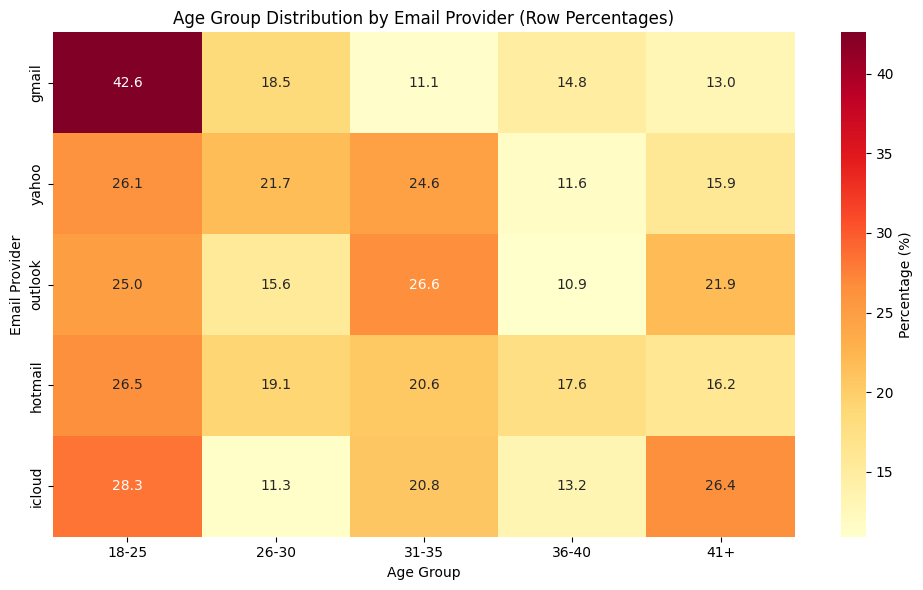

In [46]:
# Create age groups and compare by email provider
members = members.copy()
members["age_group"] = pd.cut(
    members["age"], 
    bins=[0, 25, 30, 35, 40, 100], 
    labels=["18-25", "26-30", "31-35", "36-40", "41+"]
)

# Age group distribution by email provider (counts and percentages)
age_group_provider_crosstab = pd.crosstab(members["email_provider"], members["age_group"])
age_group_provider_percentage = age_group_provider_crosstab.div(age_group_provider_crosstab.sum(axis=1), axis=0) * 100

print("Age Group distribution by Email Provider (Row Percentages):")
print(age_group_provider_percentage.round(2))

# Heatmap
plt.figure(figsize=(10, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
age_group_order = ["18-25", "26-30", "31-35", "36-40", "41+"]
sns.heatmap(age_group_provider_percentage.loc[provider_order, age_group_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Age Group Distribution by Email Provider (Row Percentages)")
plt.xlabel("Age Group")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


In [47]:
# Compare Email Provider vs Area Code
# Merge orders with customers to get area_code
orders_with_area_for_provider = orders.merge(customers[["email", "area_code"]], on="email", how="left")

# Extract email provider if not already present in orders
if "email_provider" not in orders_with_area_for_provider.columns:
    orders_with_area_for_provider["email_provider"] = orders_with_area_for_provider["email"].str.split("@").str[1].str.split(".").str[0]

# Create crosstab of email provider vs area code
provider_area_crosstab = pd.crosstab(orders_with_area_for_provider["email_provider"], orders_with_area_for_provider["area_code"])

# Calculate percentages (row-wise)
provider_area_percentage = provider_area_crosstab.div(provider_area_crosstab.sum(axis=1), axis=0) * 100

print("Email Provider vs Area Code (Counts):")
print(provider_area_crosstab)

print("\nEmail Provider vs Area Code (Row Percentages):")
print(provider_area_percentage.round(2))


Email Provider vs Area Code (Counts):
area_code       289  365  416  437  647  905
email_provider                              
gmail            92  162  100  128  104  156
hotmail         166  159  200  163  146  136
icloud          197  183  159   97   88  166
outlook         120  176  125  121  200  222
yahoo           136  120   73  219  177  209

Email Provider vs Area Code (Row Percentages):
area_code         289    365    416    437    647    905
email_provider                                          
gmail           12.40  21.83  13.48  17.25  14.02  21.02
hotmail         17.11  16.39  20.62  16.80  15.05  14.02
icloud          22.13  20.56  17.87  10.90   9.89  18.65
outlook         12.45  18.26  12.97  12.55  20.75  23.03
yahoo           14.56  12.85   7.82  23.45  18.95  22.38


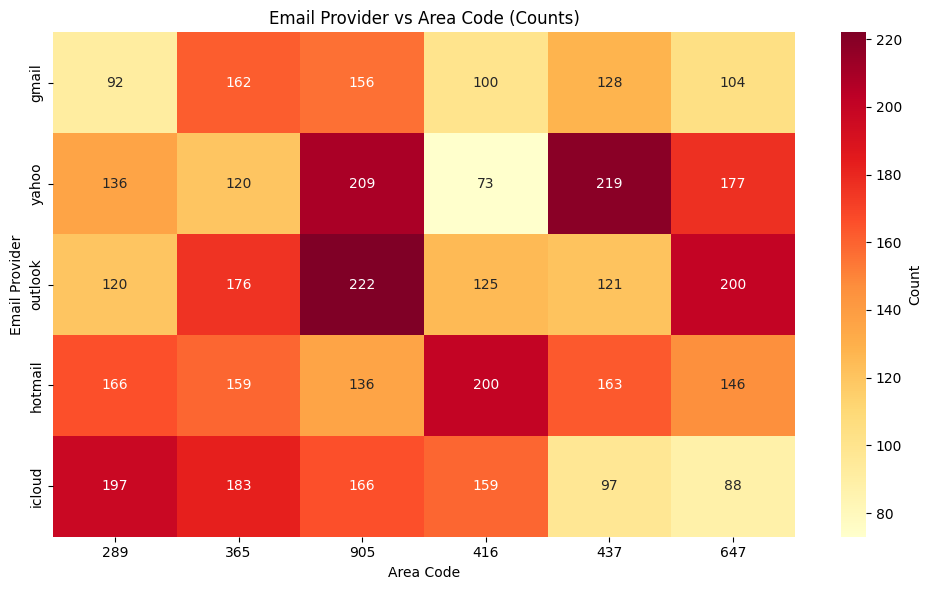

In [50]:
# Heatmap: Email Provider vs Area Code (Counts)
plt.figure(figsize=(10, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
area_order = ["289", "365", "905", "416", "437", "647"]  # Outer Belt first, then Toronto Core
sns.heatmap(provider_area_crosstab.loc[provider_order, area_order], annot=True, fmt="d", cmap="YlOrRd", cbar_kws={"label": "Count"})
plt.title("Email Provider vs Area Code (Counts)")
plt.xlabel("Area Code")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


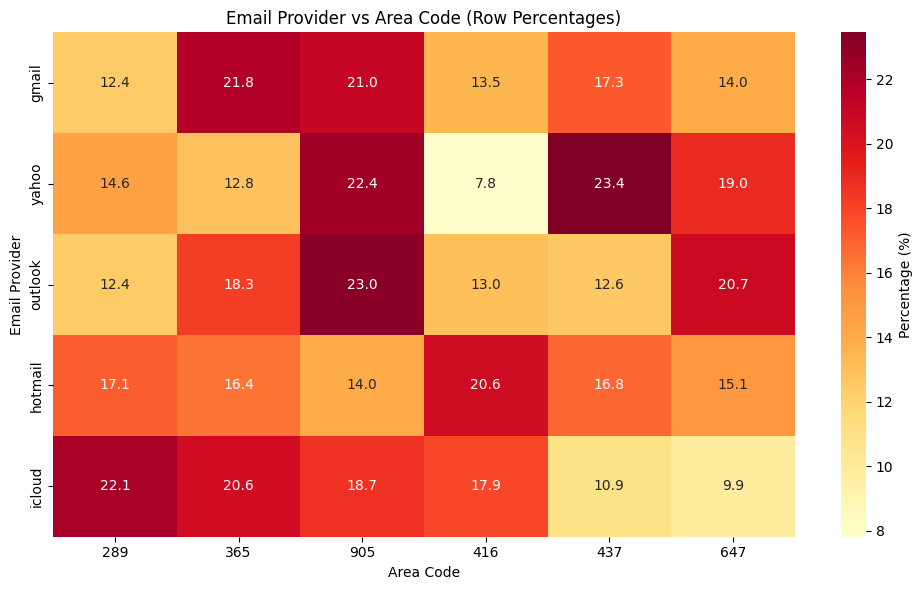

In [51]:
# Heatmap: Email Provider vs Area Code (Percentages)
plt.figure(figsize=(10, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
area_order = ["289", "365", "905", "416", "437", "647"]  # Outer Belt first, then Toronto Core
sns.heatmap(provider_area_percentage.loc[provider_order, area_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Email Provider vs Area Code (Row Percentages)")
plt.xlabel("Area Code")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


In [52]:
# Compare Email Provider vs Area Group (Outer Belt vs Toronto Core)
# Merge orders with customers to get area_group
TORONTO_CORE = {"416", "647", "437"}
OUTER_BELT = {"905", "289", "365"}

# Ensure customers has area_code and area_group
if "area_code" not in customers.columns:
    customers = customers.copy()
    customers["area_code"] = customers["phone"].str.split("-").str[1]

if "area_group" not in customers.columns:
    customers = customers.copy()
    customers["area_group"] = customers["area_code"].map(
        lambda ac: "Toronto Core (416/647/437)" if ac in TORONTO_CORE
        else ("Outer Belt (905/289/365)" if ac in OUTER_BELT else "Other")
    )

# Merge orders with customers to get area_group
orders_with_area_group_for_provider = orders.merge(customers[["email", "area_group"]], on="email", how="left")

# Extract email provider if not already present
if "email_provider" not in orders_with_area_group_for_provider.columns:
    orders_with_area_group_for_provider["email_provider"] = orders_with_area_group_for_provider["email"].str.split("@").str[1].str.split(".").str[0]

# Create crosstab of email provider vs area group
provider_area_group_crosstab = pd.crosstab(orders_with_area_group_for_provider["email_provider"], orders_with_area_group_for_provider["area_group"])

# Calculate percentages (row-wise)
provider_area_group_percentage = provider_area_group_crosstab.div(provider_area_group_crosstab.sum(axis=1), axis=0) * 100

print("Email Provider vs Area Group (Counts):")
print(provider_area_group_crosstab)

print("\nEmail Provider vs Area Group (Row Percentages):")
print(provider_area_group_percentage.round(2))


Email Provider vs Area Group (Counts):
area_group      Outer Belt (905/289/365)  Toronto Core (416/647/437)
email_provider                                                      
gmail                                410                         332
hotmail                              461                         509
icloud                               546                         344
outlook                              518                         446
yahoo                                465                         469

Email Provider vs Area Group (Row Percentages):
area_group      Outer Belt (905/289/365)  Toronto Core (416/647/437)
email_provider                                                      
gmail                              55.26                       44.74
hotmail                            47.53                       52.47
icloud                             61.35                       38.65
outlook                            53.73                       46.27
yahoo          

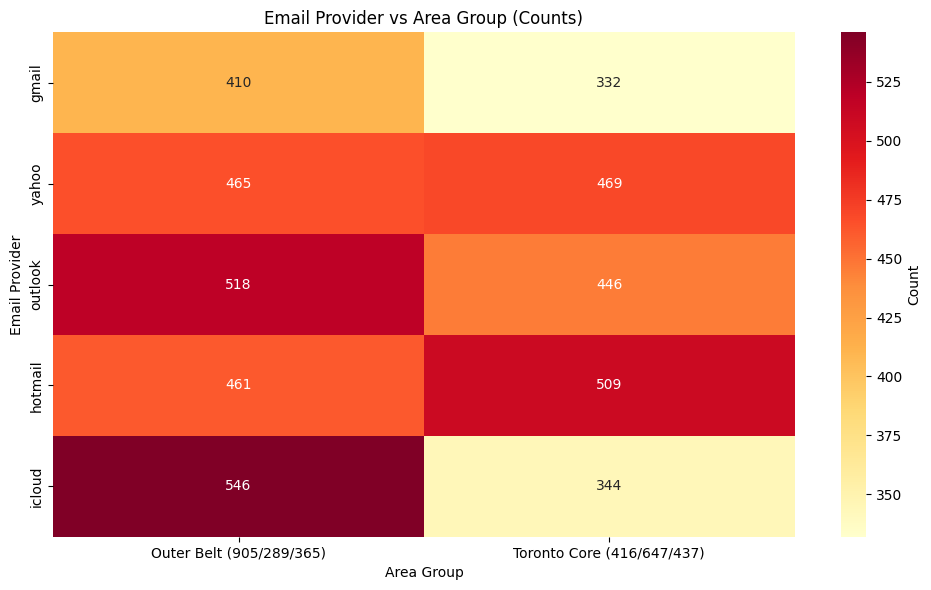

In [53]:
# Heatmap: Email Provider vs Area Group (Counts)
plt.figure(figsize=(10, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
area_group_order = ["Outer Belt (905/289/365)", "Toronto Core (416/647/437)"]
# Only include columns that exist in the crosstab
existing_groups = [g for g in area_group_order if g in provider_area_group_crosstab.columns]
sns.heatmap(provider_area_group_crosstab.loc[provider_order, existing_groups], annot=True, fmt="d", cmap="YlOrRd", cbar_kws={"label": "Count"})
plt.title("Email Provider vs Area Group (Counts)")
plt.xlabel("Area Group")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


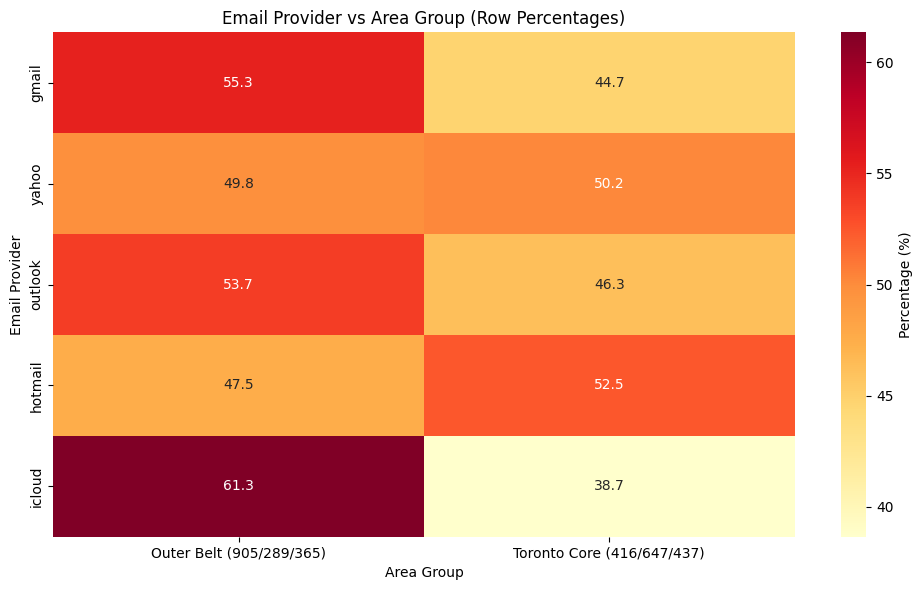

In [54]:
# Heatmap: Email Provider vs Area Group (Percentages)
plt.figure(figsize=(10, 6))
provider_order = ["gmail", "yahoo", "outlook", "hotmail", "icloud"]
area_group_order = ["Outer Belt (905/289/365)", "Toronto Core (416/647/437)"]
# Only include columns that exist in the crosstab
existing_groups = [g for g in area_group_order if g in provider_area_group_percentage.columns]
sns.heatmap(provider_area_group_percentage.loc[provider_order, existing_groups], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Email Provider vs Area Group (Row Percentages)")
plt.xlabel("Area Group")
plt.ylabel("Email Provider")
plt.tight_layout()
plt.show()


In [55]:
# Age vs Occupation comparison
# Age statistics by Occupation
age_by_occupation = members.groupby("occupation")["age"].agg([
    "count", "mean", "median", "std", "min", "max"
]).round(2)

print("Age Statistics by Occupation:")
print(age_by_occupation)


Age Statistics by Occupation:
                      count   mean  median    std  min  max
occupation                                                 
Accountant               18  29.28    28.0   7.63   18   42
Barista                  19  28.63    29.0   7.11   18   42
Chef                     12  33.33    31.5   9.84   21   58
Consultant               18  32.67    32.0  10.51   18   54
Customer Service Rep     13  30.85    28.0  11.95   18   56
Data Analyst              9  29.11    27.0   8.31   19   42
Electrician              20  31.10    32.0   8.30   18   47
Graphic Designer         23  34.61    34.0   9.96   18   57
HR Coordinator           14  32.86    31.0  10.90   18   58
Marketing Specialist     16  31.75    34.5   8.73   18   43
Nurse                    23  32.65    31.0   9.12   18   48
Operations Manager       10  31.00    31.5   6.57   20   44
Product Manager          15  33.60    36.0   9.02   18   49
Project Manager           9  32.56    31.0  11.52   18   53
Research A

Age Group distribution by Occupation (Row Percentages):
age_group             18-25  26-30  31-35  36-40    41+
occupation                                             
Accountant            33.33  22.22  22.22  11.11  11.11
Barista               36.84  26.32  15.79  15.79   5.26
Chef                  16.67  25.00  25.00  16.67  16.67
Consultant            27.78  16.67  16.67  16.67  22.22
Customer Service Rep  38.46  15.38  23.08   0.00  23.08
Data Analyst          33.33  33.33   0.00  22.22  11.11
Electrician           30.00  15.00  25.00  20.00  10.00
Graphic Designer      26.09   4.35  34.78   8.70  26.09
HR Coordinator        21.43  28.57  14.29  14.29  21.43
Marketing Specialist  31.25   6.25  37.50   0.00  25.00
Nurse                 30.43  13.04  13.04  17.39  26.09
Operations Manager    20.00  20.00  40.00  10.00  10.00
Product Manager       26.67  13.33   6.67  26.67  26.67
Project Manager       33.33  11.11  22.22   0.00  33.33
Research Assistant    30.77  23.08  23.08   0.00

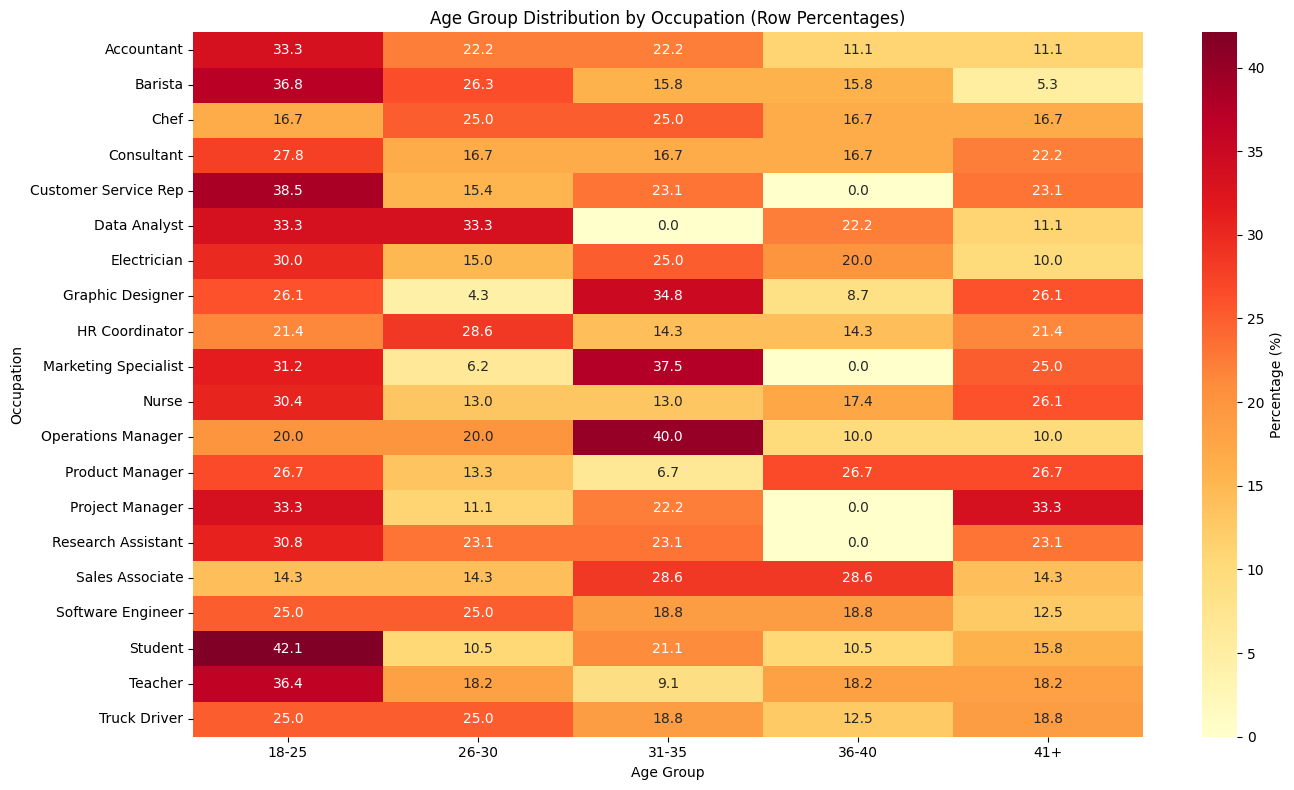

In [56]:
# Age group distribution by Occupation (using age_group from previous cell)
age_group_occupation_crosstab = pd.crosstab(members["occupation"], members["age_group"])
age_group_occupation_percentage = age_group_occupation_crosstab.div(age_group_occupation_crosstab.sum(axis=1), axis=0) * 100

print("Age Group distribution by Occupation (Row Percentages):")
print(age_group_occupation_percentage.round(2))

# Heatmap
plt.figure(figsize=(14, 8))
occupation_order = sorted(age_group_occupation_percentage.index)
age_group_order = ["18-25", "26-30", "31-35", "36-40", "41+"]
sns.heatmap(age_group_occupation_percentage.loc[occupation_order, age_group_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Age Group Distribution by Occupation (Row Percentages)")
plt.xlabel("Age Group")
plt.ylabel("Occupation")
plt.tight_layout()
plt.show()


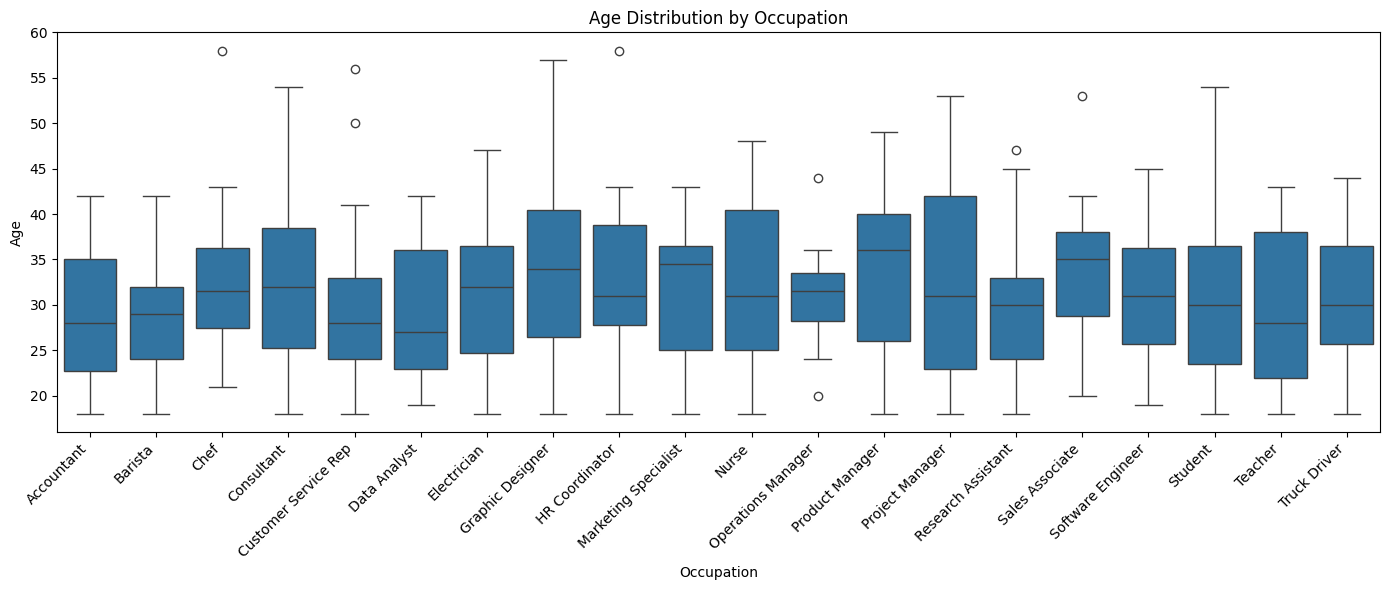

In [57]:
# Boxplot: Age distribution by Occupation
plt.figure(figsize=(14, 6))
occupation_order = sorted(members["occupation"].unique())
sns.boxplot(data=members, x="occupation", y="age", order=occupation_order)
plt.title("Age Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Age")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [58]:
# Age vs Area Code comparison
# Merge members with customers to get area_code
members_with_area_code = members.merge(customers[["email", "area_code"]], on="email", how="left")

# Age statistics by Area Code
age_by_area = members_with_area_code.groupby("area_code")["age"].agg([
    "count", "mean", "median", "std", "min", "max"
]).round(2)

print("Age Statistics by Area Code:")
print(age_by_area)


Age Statistics by Area Code:
           count   mean  median   std  min  max
area_code                                      
289           51  30.41    30.0  8.66   18   53
365           53  31.45    30.0  8.33   18   54
416           49  31.04    30.0  9.48   18   57
437           47  32.38    32.0  9.75   18   58
647           50  31.66    32.0  8.90   18   58
905           58  32.83    32.5  9.10   18   53


Age Group distribution by Area Code (Row Percentages):
age_group  18-25  26-30  31-35  36-40    41+
area_code                                   
289        31.37  21.57  17.65  15.69  13.73
365        30.19  20.75  15.09  16.98  16.98
416        32.65  18.37  26.53   8.16  14.29
437        27.66  17.02  17.02  14.89  23.40
647        28.00  18.00  26.00  10.00  18.00
905        25.86  10.34  24.14  15.52  24.14


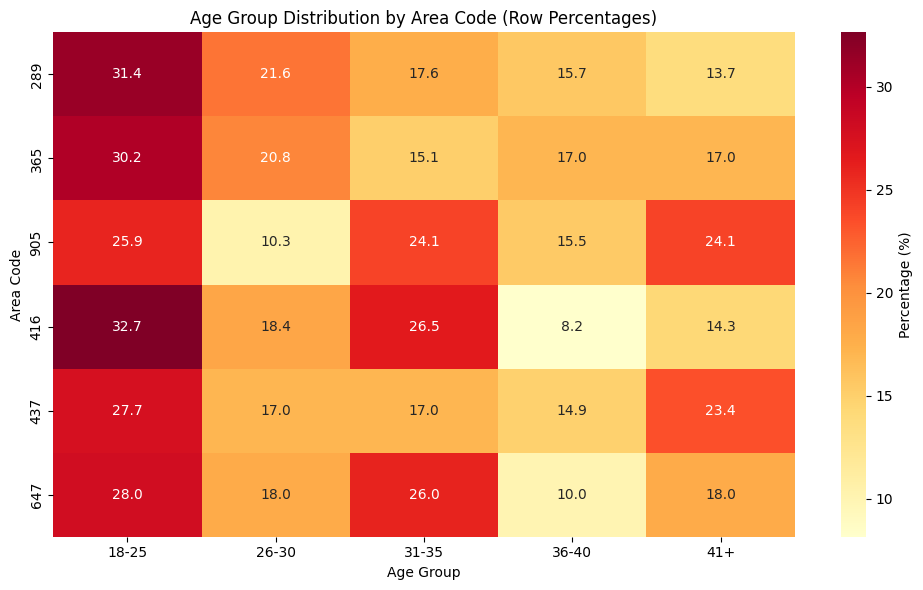

In [59]:
# Age group distribution by Area Code
# Ensure age_group exists in members_with_area_code
if "age_group" not in members_with_area_code.columns:
    members_with_area_code = members_with_area_code.copy()
    members_with_area_code["age_group"] = pd.cut(
        members_with_area_code["age"], 
        bins=[0, 25, 30, 35, 40, 100], 
        labels=["18-25", "26-30", "31-35", "36-40", "41+"]
    )

age_group_area_crosstab = pd.crosstab(members_with_area_code["area_code"], members_with_area_code["age_group"])
age_group_area_percentage = age_group_area_crosstab.div(age_group_area_crosstab.sum(axis=1), axis=0) * 100

print("Age Group distribution by Area Code (Row Percentages):")
print(age_group_area_percentage.round(2))

# Heatmap
plt.figure(figsize=(10, 6))
area_order = ["289", "365", "905", "416", "437", "647"]  # Outer Belt first, then Toronto Core
age_group_order = ["18-25", "26-30", "31-35", "36-40", "41+"]
sns.heatmap(age_group_area_percentage.loc[area_order, age_group_order], annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Percentage (%)"})
plt.title("Age Group Distribution by Area Code (Row Percentages)")
plt.xlabel("Age Group")
plt.ylabel("Area Code")
plt.tight_layout()
plt.show()


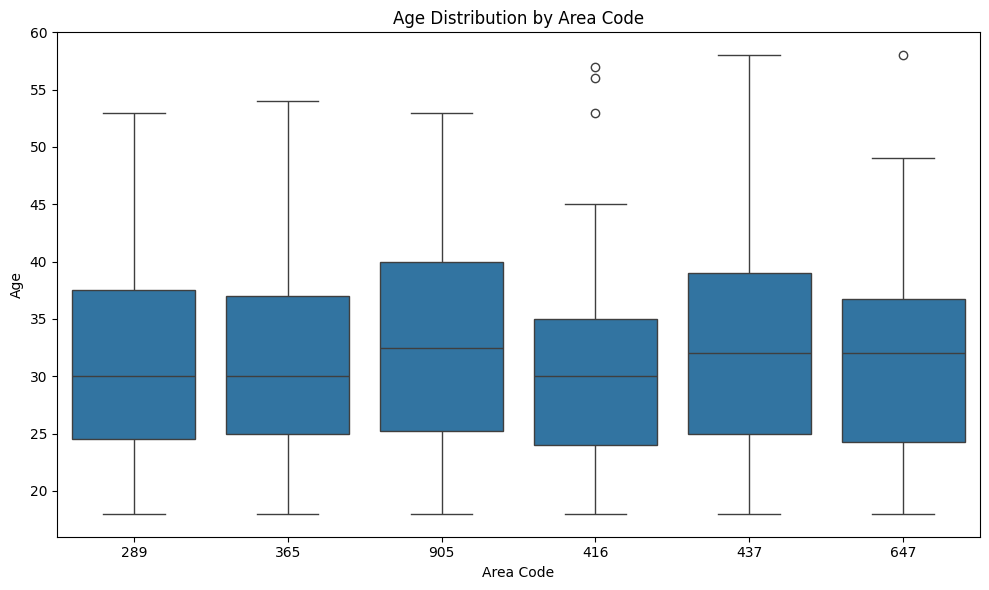

In [60]:
# Boxplot: Age distribution by Area Code
plt.figure(figsize=(10, 6))
area_order = ["289", "365", "905", "416", "437", "647"]  # Outer Belt first, then Toronto Core
sns.boxplot(data=members_with_area_code, x="area_code", y="age", order=area_order)
plt.title("Age Distribution by Area Code")
plt.xlabel("Area Code")
plt.ylabel("Age")
plt.tight_layout()
plt.show()
